# A figure to show the before and after af the removal of the ac stark shift
- currently imagining a figure with two side by sides of rabi and ccd with their ac stark shift removed

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet

In [3]:
steel_blue, plum = "#4682B4", "#B44682"
deep_magenta = "#C12769"


## Rabi


In [4]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005



# Integration parameters
tol = 10**-7
evaluation_points = 2001
evaluation_time = 8/(rabi_freq)

# iteration parameters
detunings = np.linspace(0, 4*rabi_freq, 1000)



fids_rabi_raw = []
fids_rabi_det_compensated = []
fids_rabi_ac_compensated = []




for detuning in detunings:
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+detuning, driving_freq=driving_freq, rabi_freq=rabi_freq)

    # calculate how the bare detuned qubit fairs
    fid_rabi_raw = qt.calculate_fidelities(identity, Us_driving_frame, 2)
    fids_rabi_raw.append(fid_rabi_raw)


    # then compensate for the ac stark effect and recalculate the fidelity
    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
    fid_rabi_ac_compensated = qt.calculate_fidelities(identity, Us_effective_rabi, 2)
    fids_rabi_ac_compensated.append(fid_rabi_ac_compensated)

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, -detuning, times)
    fid_rabi_det_compensated = qt.calculate_fidelities(identity, transformed_Us, 2)
    fids_rabi_det_compensated.append(fid_rabi_det_compensated)



In [5]:
# Find the closest time to the optimal measurement time
closest_time = times[np.argmin(np.abs(times - (4 / rabi_freq)))]
time_index = np.argmin(np.abs(times - (4 / rabi_freq)))

# Extract fidelities at the optimal measurement time
final_fids_rabi_raw = [fid[time_index] for fid in fids_rabi_raw]
final_fids_rabi_det = [fid[time_index] for fid in fids_rabi_det_compensated]
final_fids_rabi_ac = [fid[time_index] for fid in fids_rabi_ac_compensated]

# Normalize detunings
detunings_normalized = detunings / rabi_freq

## CCD

In [6]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0, rabi_freq/4, rabi_freq, 0


# Integration parameters
# Integration parameters
tol = 10**-7
evaluation_points = 2001
evaluation_time = 8/(rabi_freq)

# iteration parameters
detunings = np.linspace(0, 4*rabi_freq, 1000)



fids_ccd_raw = []
fids_ccd_det_compensated = []
fids_ccd_ac_compensated = []


for detuning in detunings:
    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq-detuning, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m,
                            atol=tol, rtol=tol)
    

    fid_ccd_raw = qt.calculate_fidelities(identity, Us_driving_frame, 2)
    fids_ccd_raw.append(fid_ccd_raw)
    # then compensate for the ac stark effect and recalculate the fidelity

    ccd_floquet_freq = np.sign(detuning)*2*ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m)[4]

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, ccd_floquet_freq, times)
    
    fid_ccd_compensated = qt.calculate_fidelities(identity, transformed_Us, 2)


    fids_ccd_ac_compensated.append(fid_ccd_compensated)

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, detuning, times)
    fid_ccd_det_compensated = qt.calculate_fidelities(identity, transformed_Us, 2)
    fids_ccd_det_compensated.append(fid_ccd_det_compensated)




In [7]:
# Find the closest time to the optimal measurement time
closest_time = times[np.argmin(np.abs(times - (4 / rabi_freq)))]
time_index = np.argmin(np.abs(times - (4 / rabi_freq)))

# Extract fidelities at the optimal measurement time
final_fids_ccd_raw = [fid[time_index] for fid in fids_ccd_raw]
final_fids_ccd_det = [fid[time_index] for fid in fids_ccd_det_compensated]
final_fids_ccd_ac = [fid[time_index] for fid in fids_ccd_ac_compensated]

# Normalize detunings
detunings_normalized = detunings / rabi_freq

# now create the combined plot

In [12]:
vmin = 1/3
vmax = 1
detuning_scale = detunings/rabi_freq
time_scale = times*rabi_freq

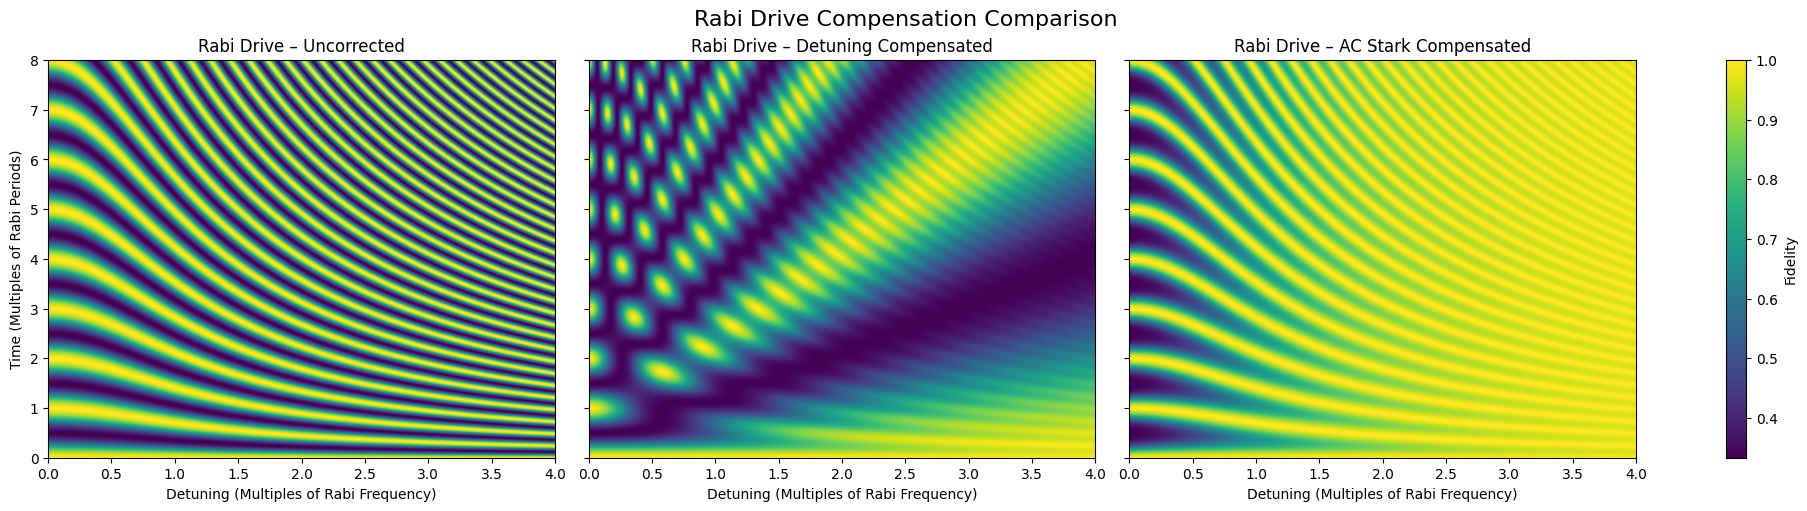

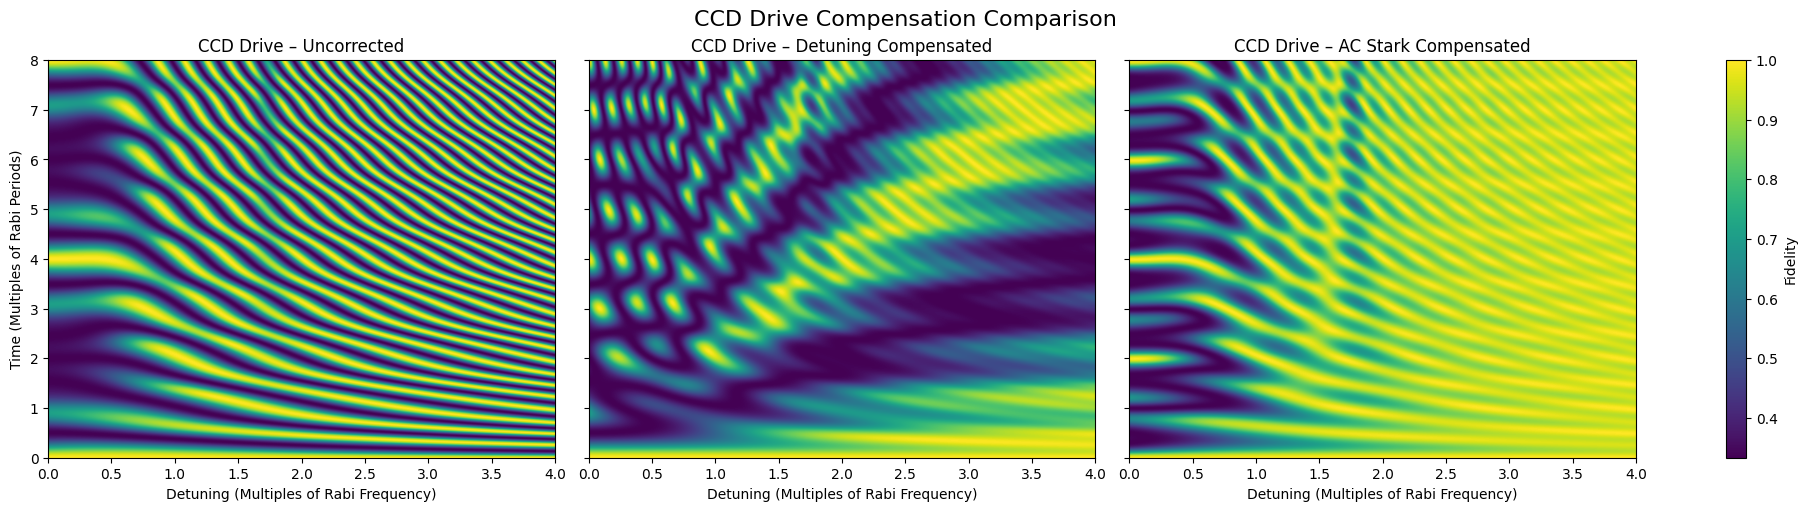

In [13]:
# Rabi Figure
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True, constrained_layout=True)

titles = [
    'Rabi Drive – Uncorrected',
    'Rabi Drive – Detuning Compensated',
    'Rabi Drive – AC Stark Compensated'
]
data = [
    fids_rabi_raw,
    fids_rabi_det_compensated,
    fids_rabi_ac_compensated
]

# Plot
for ax, title, fid in zip(axs, titles, data):
    im = ax.imshow(
        np.array(fid).T, aspect='auto',
        extent=[detuning_scale[0], detuning_scale[-1], time_scale[0], time_scale[-1]],
        origin='lower', cmap='viridis',
        vmin=vmin, vmax=vmax
    )
    ax.set_title(title)
    ax.set_xlabel('Detuning (Multiples of Rabi Frequency)')
axs[0].set_ylabel('Time (Multiples of Rabi Periods)')

# Shared colorbar
cbar = fig.colorbar(im, ax=axs.ravel().tolist(), location='right', label='Fidelity')

fig.suptitle('Rabi Drive Compensation Comparison', fontsize=16)
fig.savefig('/Users/archie/documents/year4/project/Figures/rabi_compensation_comparison.png', dpi=600)
plt.show()

# CCD Figure
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True, constrained_layout=True)

titles = [
    'CCD Drive – Uncorrected',
    'CCD Drive – Detuning Compensated',
    'CCD Drive – AC Stark Compensated'
]
data = [
    fids_ccd_raw,
    fids_ccd_det_compensated,
    fids_ccd_ac_compensated
]

# Plot
for ax, title, fid in zip(axs, titles, data):
    im = ax.imshow(
        np.array(fid).T, aspect='auto',
        extent=[detuning_scale[0], detuning_scale[-1], time_scale[0], time_scale[-1]],
        origin='lower', cmap='viridis',
        vmin=vmin, vmax=vmax
    )
    ax.set_title(title)
    ax.set_xlabel('Detuning (Multiples of Rabi Frequency)')
axs[0].set_ylabel('Time (Multiples of Rabi Periods)')

# Shared colorbar
cbar = fig.colorbar(im, ax=axs.ravel().tolist(), location='right', label='Fidelity')

fig.suptitle('CCD Drive Compensation Comparison', fontsize=16)
fig.savefig('/Users/archie/documents/year4/project/Figures/ccd_compensation_comparison.png', dpi=600)
plt.show()

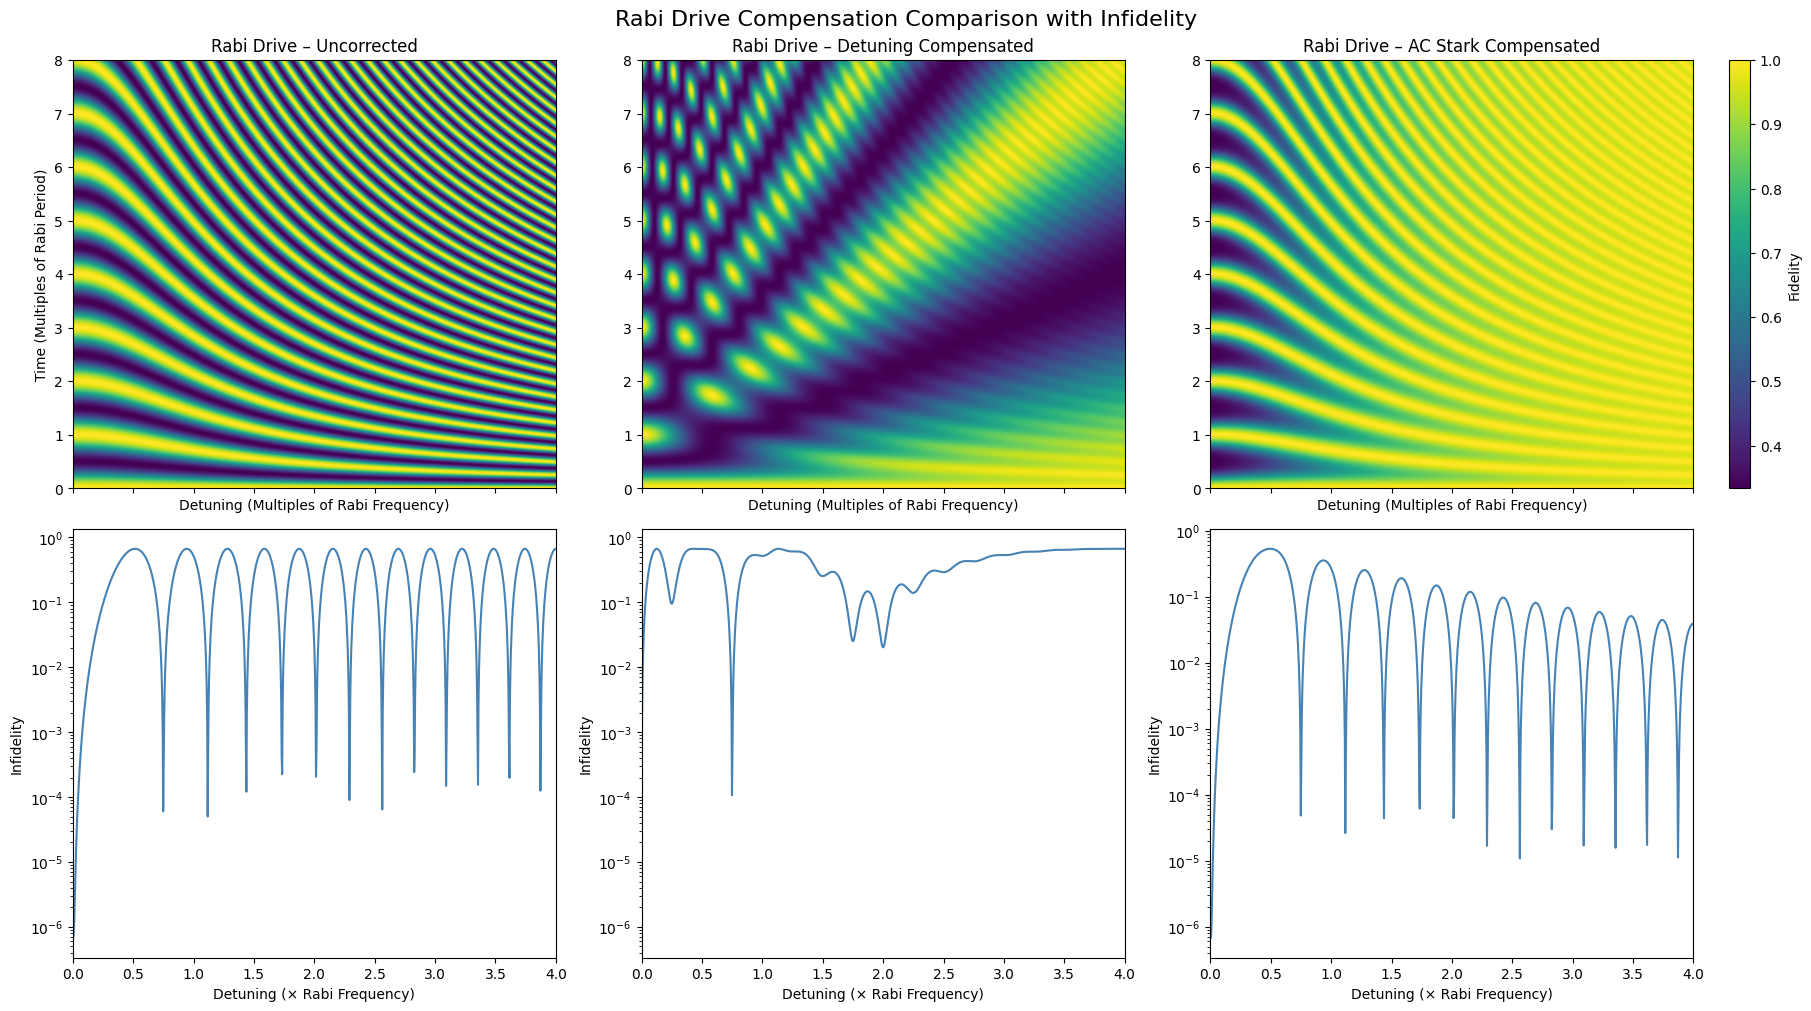

/var/folders/r1/4bsh28x136nb61xfvz5ly0dh0000gn/T/ipykernel_13066/4207472308.py:94: UserWarning: Adding colorbar to a different Figure <Figure size 1800x1000 with 7 Axes> than <Figure size 1800x1000 with 7 Axes> which fig.colorbar is called on.
  cbar = fig_rabi.colorbar(im, ax=axs_ccd[0, 2])


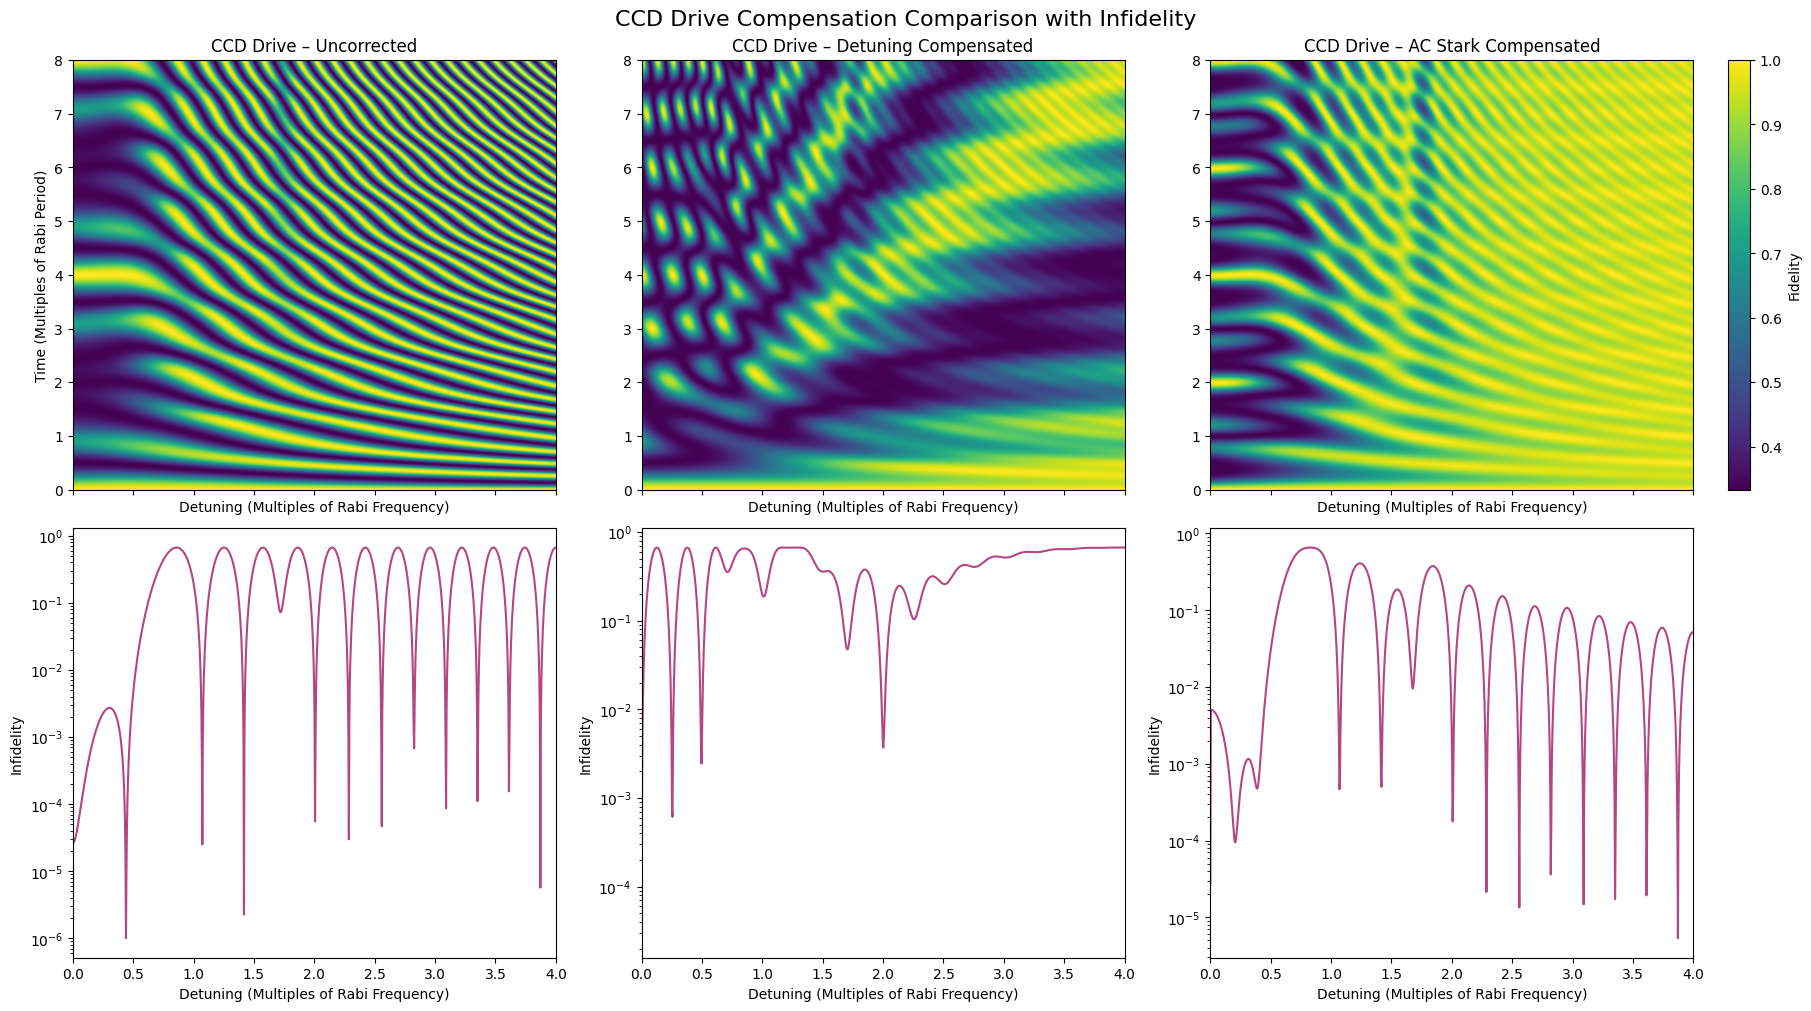

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# === RABI Infidelity Plot ===
fig_rabi, axs_rabi = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True, sharex='col')

titles_rabi = [
    'Rabi Drive – Uncorrected',
    'Rabi Drive – Detuning Compensated',
    'Rabi Drive – AC Stark Compensated'
]

data_rabi = [
    fids_rabi_raw,
    fids_rabi_det_compensated,
    fids_rabi_ac_compensated
]

infidelity_data_rabi = [
    1 - np.array(final_fids_rabi_raw),
    1 - np.array(final_fids_rabi_det),
    1 - np.array(final_fids_rabi_ac)
]

# Plot Rabi fidelity heatmaps (top row)
for ax, title, fid in zip(axs_rabi[0], titles_rabi, data_rabi):
    im = ax.imshow(
        np.array(fid).T, aspect='auto',
        extent=[detunings_normalized[0], detunings_normalized[-1], time_scale[0], time_scale[-1]],
        origin='lower', cmap='viridis',
        vmin=vmin, vmax=vmax
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Detuning (Multiples of Rabi Frequency)', fontsize=10)
axs_rabi[0, 0].set_ylabel('Time (Multiples of Rabi Period)', fontsize=10)

# Plot Rabi infidelity (semilog y-axis) (bottom row)
for ax, infidelity in zip(axs_rabi[1], infidelity_data_rabi):
    ax.semilogy(detunings_normalized, infidelity, color=steel_blue)
    ax.set_xlabel('Detuning (× Rabi Frequency)', fontsize=10)
    ax.set_ylabel('Infidelity', fontsize=10)

# Shared colorbar
# fig_rabi.colorbar(im, ax=axs_rabi[0, :], location='right', label='Fidelity')
cbar = fig_rabi.colorbar(im, ax=axs_rabi[0, 2])
cbar.set_label('Fidelity')

fig_rabi.suptitle('Rabi Drive Compensation Comparison with Infidelity', fontsize=16)
fig_rabi.savefig('/Users/archie/documents/year4/project/Figures/rabi_compensation_with_infidelity.png', dpi=600)
plt.show()


# === CCD Infidelity Plot ===
fig_ccd, axs_ccd = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True, sharex='col')

titles_ccd = [
    'CCD Drive – Uncorrected',
    'CCD Drive – Detuning Compensated',
    'CCD Drive – AC Stark Compensated'
]

data_ccd = [
    fids_ccd_raw,
    fids_ccd_det_compensated,
    fids_ccd_ac_compensated
]

infidelity_data_ccd = [
    1 - np.array(final_fids_ccd_raw),
    1 - np.array(final_fids_ccd_det),
    1 - np.array(final_fids_ccd_ac)
]

# Plot CCD fidelity heatmaps (top row)
for ax, title, fid in zip(axs_ccd[0], titles_ccd, data_ccd):
    im = ax.imshow(
        np.array(fid).T, aspect='auto',
        extent=[detunings_normalized[0], detunings_normalized[-1], time_scale[0], time_scale[-1]],
        origin='lower', cmap='viridis',
        vmin=vmin, vmax=vmax
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Detuning (Multiples of Rabi Frequency)', fontsize=10)
axs_ccd[0, 0].set_ylabel('Time (Multiples of Rabi Period)', fontsize=10)

# Plot CCD infidelity (semilog y-axis) (bottom row)
for ax, infidelity in zip(axs_ccd[1], infidelity_data_ccd):
    ax.semilogy(detunings_normalized, infidelity, color=plum)
    ax.set_xlabel('Detuning (Multiples of Rabi Frequency)', fontsize=10)
    ax.set_ylabel('Infidelity', fontsize=10)

# Shared colorbar
# fig_ccd.colorbar(im, ax=axs_ccd[0, :], location='right', label='Fidelity')
cbar = fig_rabi.colorbar(im, ax=axs_ccd[0, 2])
cbar.set_label('Fidelity')

fig_ccd.suptitle('CCD Drive Compensation Comparison with Infidelity', fontsize=16)
fig_ccd.savefig('/Users/archie/documents/year4/project/Figures/ccd_compensation_with_infidelity.png', dpi=600)
plt.show()